# Genuine LLM Fuzzy-Unification with a Certificate-Bounded Hallucination Guarantee

**A runnable demo of the kinship (CLUTRR) setting.**

This notebook is a faithful, minimal-change extraction of the experiment's `method.py`,
focused on the self-contained **kinship** half of the pipeline. It demonstrates the core
claim of the paper:

> A training-free *abstain-on-collapse certificate* bounds the hallucination cost of
> feeding **genuinely-fuzzy** LLM reads into a sound symbolic closure engine.

**The story.** An atomic kinship fact (e.g. *"B is A's father"*, type `inv-child`) is
re-rendered with an **informal, under-specified term** (*"B is A's guardian"*) that maps to
a *type-disjunction* (`parent` **or** `grandparent`). A real LLM
(`google/gemini-3.1-flash-lite`, temp 0) emits a **calibrated sub-1.0 disjunction** over the
possible kinship types — *not* a single memorized answer. That disjunction is seeded into a
sound forward-union closure engine, and the output contract is:

| `|D_query|` | decision  | meaning                                            |
|-------------|-----------|----------------------------------------------------|
| `== 1`      | `COMMIT`  | the closure pins a single relation → answer it     |
| `== 0`      | `COLLAPSE`| the disjunction was unsound → abstain (Mode-B)     |
| `> 1`       | `ABSTAIN` | still ambiguous → keep the disjunction, abstain    |

We measure (1) **calibration** of the fuzzy reads (headline: `frac_conf_1p0 = 0.00` vs the
old memorized "Mode-P" recall at `1.00`), and (2) a **risk-coverage** tradeoff showing the
certificate's *confident-wrong rate is 0.0* where a naive commit-the-argmax baseline is
confidently wrong on ~25% of queries.

> **Demo scope.** The ~6 distinct per-term LLM reads are *term-conditioned, temperature-0 and
> sha256-cached*, so they are **baked into the data file** (the exact disjunctions the model
> emitted). The notebook therefore reproduces the genuine calibrated reads **deterministically,
> with no API key and \$0 spend**. All symbolic code (the closure engine, calibration, and
> risk-coverage analysis) is the original, run live.

In [1]:
# --- Dependencies (Colab-safe install pattern) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# numpy + matplotlib are pre-installed on Colab; install locally only (behind the guard)
# so a fresh local kernel matches Colab's exact versions.
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "matplotlib==3.10.0")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors method.py / kinship.py; loguru replaced by a tiny print-shim) ---
from __future__ import annotations
import hashlib
import json
import os
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt


# The original modules use loguru; in the notebook we use a minimal stand-in so the
# verbatim `logger.info(...)` calls below keep working without the extra dependency.
class _Logger:
    def info(self, *a):    print(*a)
    def warning(self, *a): print("WARN:", *a)
logger = _Logger()

In [3]:
# --- Data loading: GitHub raw URL with a local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-5/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
# --- Load the curated subset and unpack its pieces ---
data = load_data()

comp        = data["composition_table"]   # the finite CLUTRR kinship composition table
AMBIG_KIN   = data["kinship_term_map"]     # informal term -> admissible base types
modeP       = data["modeP_memorized"]      # the iter-4 memorized "Mode-P" calibration (contrast)
gen_rows    = data["kinship_rows"]         # ~100 clean CLUTRR multi-hop stories

# The per-term fuzzy reads the LLM actually emitted (temp 0, cached). S_pred -> frozenset to
# match the original read objects produced by parse_fuzzy_read().
reads = {t: {"S_pred": frozenset(r["S_pred"]), "conf": r["conf"],
             "raw_max_p": r["raw_max_p"], "parse_fail": r["parse_fail"]}
         for t, r in data["kinship_reads"].items()}

print(f"loaded {len(gen_rows)} CLUTRR rows, {len(reads)} term-conditioned LLM reads")
print("ambiguous terms:", list(AMBIG_KIN))

loaded 100 CLUTRR rows, 6 term-conditioned LLM reads
ambiguous terms: ['guardian', 'descendant', 'family elder', 'sibling-figure', 'relative by marriage', 'younger relative']


In [5]:
# --- CONFIG: all tunable knobs in one place ---------------------------------
# Start small; everything here is pure-Python symbolic work and runs in well under a second,
# so the demo defaults already cover the whole curated subset.
SEED            = 20260617   # deterministic bootstrap / hashing seed (method.py constant)
CAP_PER_SETTING = 200        # cap on calibration reads AND certificate-pool queries
                             #   (original full run: --max-per-setting 400 over the FULL 16k-row CLUTRR)
BOOTSTRAP_B     = 2000       # paired/clustered bootstrap resamples for the 95% CIs
ECE_N_BINS      = 10         # reliability-diagram bins for the calibration ECE

## 1 · The symbolic half — kinship closure engine

The kinship calculus is a **finite composition table** over 11 abstract relation types. As the
CLUTRR card states, it is *not* a full relation algebra (no general intersection/converse
closure), so the sound closure is a **forward least-fixpoint *union* derivation** over *defined*
compositions only: undefined compositions add nothing (sound — "unknown", never a wrong fact).

The code below is the original `kinship.py` engine, verbatim: the `Kinship` calculus, the
forward closure, the Mode-A query wrapper with the `COMMIT / ABSTAIN(conflict) / ABSTAIN(no-path)`
output contract, and a derivation-trace reconstructor for the auditable proof skeleton.

In [6]:
# ===== kinship.py (verbatim): finite-composition closure engine =====
class Kinship:
    """Finite kinship composition calculus parsed from the dataset composition table."""

    def __init__(self, comp_table: dict):
        rt = comp_table["relation_types"]
        self.base: list[str] = list(rt.keys())  # 11 abstract relation types
        self.universe = frozenset(self.base)
        self.empty = frozenset()
        self.symmetric_types = set(comp_table["symmetric_types"])  # {'sibling','SO'}
        self.inv: dict[str, str] = {}
        for a, b in comp_table["inverse_pairs"].items():
            self.inv[a] = b
            self.inv[b] = a
        self.composition_rules = comp_table["composition_rules"]
        self.surface_forms = comp_table["surface_forms"]
        self.surface_reverse = comp_table["surface_reverse"]
        self.label_map = comp_table.get("label_map", {})
        self.label_map_reverse = comp_table.get("label_map_reverse", {})
        # ---- total converse over every base type (sound; no empties) ----
        self._conv: dict[str, str] = {}
        for t in self.base:
            if t in self.symmetric_types:
                self._conv[t] = t
            elif t in self.inv:
                self._conv[t] = self.inv[t]
            elif t == "sibling-in-law":
                # brother/sister-in-law are mutual: converse(sibling-in-law)=sibling-in-law.
                self._conv[t] = t
            else:
                self._conv[t] = t  # sound self-converse fallback (never reached for the 11 types)

    # ------------------------------------------------------------------ ops
    def conv_type(self, t: str) -> str:
        return self._conv[t]

    def compose_types(self, t1: str, t2: str):
        """Defined composition rules[t1][t2]=t3, else None (UNDEFINED == 'unknown')."""
        return self.composition_rules.get(t1, {}).get(t2)

    def label(self, s) -> str:
        s = frozenset(s)
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(t for t in self.base if t in s)

    # ------------------------------------------------------------- surface words
    def surface(self, rel_type: str, gender: str) -> str:
        g = "male" if str(gender).lower().startswith("m") else "female"
        sf = self.surface_forms.get(rel_type)
        if not sf:
            return rel_type
        return sf.get(g, sf.get("male", rel_type))

    def surface_to_type(self, surface_word: str):
        """Return (relation_type, implied_gender) or None for an unknown word."""
        w = str(surface_word).strip().lower()
        rev = self.surface_reverse.get(w)
        if rev is None:
            return None
        return rev[0], rev[1]
def _seed(kin: Kinship, atomic_edges: list[dict]):
    """Seed D with atomic edges + their converses. Returns (D, nbrs).
    D[(a,b)] = set of types; nbrs[a] = set of directed successors."""
    D: dict = defaultdict(set)
    nbrs: dict = defaultdict(set)

    def add(a, b, t):
        if t not in D[(a, b)]:
            D[(a, b)].add(t)
            nbrs[a].add(b)

    for e in atomic_edges:
        t = e["type"]
        if t not in kin.base:
            continue
        a, b = e["a"], e["b"]
        if a == b:
            continue
        add(a, b, t)
        add(b, a, kin.conv_type(t))
    return D, nbrs
def forward_closure(kin: Kinship, atomic_edges: list[dict], with_prov: bool = False):
    """Forward least-fixpoint union derivation. Returns (D, nbrs, n_fired) or, with
    with_prov, (D, nbrs, n_fired, prov) where prov[(a,c,t3)] = (a,b,c,t1,t2,t3) records
    the FIRST composition that produced type t3 on pair (a,c) (a directed-edge of the
    proof DAG; seed edges map to None).

    D[(a,b)] holds EVERY relation type derivable for the directed pair a->b; closed
    under defined composition + converse. n_fired = number of new type-additions."""
    D, nbrs = _seed(kin, atomic_edges)
    prov: dict = {}
    if with_prov:
        for (a, b), ts in D.items():
            for t in ts:
                prov.setdefault((a, b, t), None)
    Q = deque(D.keys())
    inq = set(D.keys())
    n_fired = 0

    def push(p):
        if p not in inq:
            inq.add(p)
            Q.append(p)

    def emit(a, c, t3, provtuple):
        nonlocal n_fired
        grew = False
        if t3 not in D[(a, c)]:
            D[(a, c)].add(t3)
            nbrs[a].add(c)
            if with_prov:
                prov.setdefault((a, c, t3), provtuple)
            n_fired += 1
            grew = True
        ct3 = kin.conv_type(t3)
        if ct3 not in D[(c, a)]:
            D[(c, a)].add(ct3)
            nbrs[c].add(a)
            if with_prov:
                prov.setdefault((c, a, ct3), (c, a, a, ct3, None, ct3))  # converse marker
        if grew:
            push((a, c)); push((c, a))

    while Q:
        (a, b) = Q.popleft()
        inq.discard((a, b))
        tab = list(D[(a, b)])
        # extend a->b with b->c  =>  a->c
        for c in list(nbrs[b]):
            if c == a:
                continue
            for t1 in tab:
                for t2 in list(D[(b, c)]):
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(a, c, t3, (a, b, c, t1, t2, t3))
        # extend z->a with a->b  =>  z->b   (a is the middle)
        for z in list(nbrs[a]):
            if z == b:
                continue
            for t1 in list(D[(z, a)]):
                for t2 in tab:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(z, b, t3, (z, a, b, t1, t2, t3))
    if with_prov:
        return D, nbrs, n_fired, prov
    return D, nbrs, n_fired
def _answer_from_set(kin: Kinship, R: set) -> dict:
    R = set(R)
    n = len(R)
    if n == 1:
        t = next(iter(R))
        return {"types": sorted(R), "singleton": True, "answer_type": t,
                "n_derivations": n, "mode_b_conflict": False, "no_path": False}
    if n == 0:
        return {"types": [], "singleton": False, "answer_type": None,
                "n_derivations": 0, "mode_b_conflict": False, "no_path": True}
    # n > 1 : incompatible derivations => Mode-B conflict
    rep = sorted(R, key=lambda t: kin.base.index(t))[0]  # deterministic representative
    return {"types": sorted(R), "singleton": False, "answer_type": rep,
            "n_derivations": n, "mode_b_conflict": True, "no_path": False}
def query_modeA(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> dict:
    """Mode-A forward-closure query. Returns the output-contract decision + n_fired."""
    D, nbrs, n_fired = forward_closure(kin, atomic_edges)
    R = D.get((qsrc, qtgt), set())
    out = _answer_from_set(kin, R)
    out["n_fired"] = n_fired
    return out
def derivation_trace(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt,
                     max_steps: int = 60):
    """Reconstruct ONE concrete derivation for (qsrc->qtgt) for the trace-graph:
    which (t1 o t2 -> t3) compositions fire, mirroring the gold backward proof.
    Returns a list of {a,b,c,t1,t2,t3} steps producing the answer type, or [] if the
    query is not a unique-derivation singleton."""
    D, nbrs, _, prov = forward_closure(kin, atomic_edges, with_prov=True)
    target = D.get((qsrc, qtgt), set())
    if len(target) != 1:
        return []
    goal_type = next(iter(target))
    steps = []
    stack = [(qsrc, qtgt, goal_type)]
    seen = set()
    while stack and len(steps) < max_steps:
        key = stack.pop()
        if key in seen:
            continue
        seen.add(key)
        p = prov.get(key)
        if p is None:
            continue  # seed edge (atomic fact) -- a leaf of the proof DAG
        a, b, c, t1, t2, t3 = p
        if t2 is None:
            # converse marker: unfold to the forward edge (b->a : conv(t3))
            stack.append((c, a, kin.conv_type(t3)))
            continue
        steps.append({"a": a, "b": b, "c": c, "t1": t1, "t2": t2, "t3": t3})
        stack.append((a, b, t1))
        stack.append((b, c, t2))
    steps.reverse()
    return steps
# Instantiate the calculus from the composition table shipped in the data file.
kin = Kinship(comp)
print("relation types:", kin.base)
print("converse map:", kin._conv)

relation types: ['child', 'inv-child', 'SO', 'sibling', 'grand', 'inv-grand', 'in-law', 'inv-in-law', 'sibling-in-law', 'un', 'inv-un']
converse map: {'child': 'inv-child', 'inv-child': 'child', 'SO': 'SO', 'sibling': 'sibling', 'grand': 'inv-grand', 'inv-grand': 'grand', 'in-law': 'inv-in-law', 'inv-in-law': 'in-law', 'sibling-in-law': 'sibling-in-law', 'un': 'inv-un', 'inv-un': 'un'}


## 2 · The fuzzy reads — genuinely calibrated sub-1.0 disjunctions

Each informal term maps to a *set* of admissible base types (`AMBIG_KIN`). For every such term
the LLM was asked, once, to return **every** specific kinship type it could mean, *each with a
calibrated probability in [0,1]* (probabilities need not sum to 1 — the model must not force a
single answer when the term is genuinely ambiguous). Those ~6 reads are baked into the data file.

`_assign_term` deterministically renders an atomic edge with whichever ambiguous term is
*eligible* for its true type (eligible = gold type is in the term's admissible set), so the gold
type is in the admissible set **by construction** — the soundness target is "gold in the emitted
set". Below we print the six reads the model actually emitted.

In [7]:
# ===== method.py (verbatim): deterministic term assignment =====
def _stable_hash(*parts) -> int:
    return int(hashlib.md5("|".join(str(p) for p in parts).encode()).hexdigest(), 16)
def _assign_term(term_map: dict, gold_code, *hash_parts):
    """Deterministically assign an eligible vague/ambiguous term to an edge whose true
    relation is `gold_code` (eligible = gold in the term's admissible set)."""
    eligible = [t for t, adm in term_map.items() if gold_code in adm]
    if not eligible:
        return None
    return eligible[_stable_hash(*hash_parts) % len(eligible)]
# ===== method.py (verbatim): gold atomic facts -> [{a,b,type}] =====
def _atomics_to_edges(atomic_facts):
    return [{"a": f["source_name"], "b": f["target_name"], "type": f["relation_type"]}
            for f in atomic_facts]
# Show the genuinely-fuzzy reads (note: NO read pins a single type at p=1.0).
for t in AMBIG_KIN:
    r = reads[t]
    conf = {k: round(v, 3) for k, v in r["conf"].items()}
    print(f'{t:>22s} -> emitted {sorted(r["S_pred"])}')
    print(f'{"":>22s}    p = {conf}  (max p = {r["raw_max_p"]})')

              guardian -> emitted ['SO', 'inv-child', 'inv-grand', 'inv-un', 'sibling']
                          p = {'SO': 0.05, 'inv-child': 0.4, 'sibling': 0.1, 'inv-grand': 0.2, 'inv-un': 0.2}  (max p = 0.4)
            descendant -> emitted ['child', 'grand']
                          p = {'grand': 0.3, 'child': 0.2}  (max p = 0.3)
          family elder -> emitted ['inv-child', 'inv-grand', 'inv-un']
                          p = {'inv-grand': 0.4, 'inv-child': 0.4, 'inv-un': 0.2}  (max p = 0.4)
        sibling-figure -> emitted ['inv-un', 'sibling', 'sibling-in-law']
                          p = {'sibling': 0.8, 'sibling-in-law': 0.15, 'inv-un': 0.05}  (max p = 0.8)
  relative by marriage -> emitted ['SO', 'in-law', 'inv-in-law', 'sibling-in-law']
                          p = {'sibling-in-law': 0.2, 'in-law': 0.3, 'SO': 0.2, 'inv-in-law': 0.3}  (max p = 0.3)
      younger relative -> emitted ['child', 'grand', 'sibling', 'un']
                          p = {'sibling': 0.2, 'g

## 3 · Stage 1 — Calibration of the fuzzy reads

We score each rendered edge against its gold type. Two calibration views (per the original
`score_reads`): **per-candidate** (every emitted `(type, p)` vs `type == gold`) and **top-1**
(the argmax type vs gold). The headline honesty metric is `frac_at_conf_1p0` — the fraction of
reads emitted at confidence *exactly* 1.0. A genuinely-fuzzy reader sits near **0.0**; the old
memorized "Mode-P" sat at **1.0**.

In [8]:
# ===== method.py (verbatim): ECE + reliability =====
def compute_ece(pairs, n_bins: int = 10):
    """pairs: list of (confidence, correct{0,1}).  Returns (ece, reliability_points, n)."""
    pairs = [(float(c), float(y)) for c, y in pairs if c is not None]
    n = len(pairs)
    if n == 0:
        return None, [], 0
    bins = [[] for _ in range(n_bins)]
    for c, y in pairs:
        idx = min(n_bins - 1, max(0, int(c * n_bins)))
        bins[idx].append((c, y))
    ece = 0.0
    rel = []
    for bi, b in enumerate(bins):
        lo, hi = bi / n_bins, (bi + 1) / n_bins
        if not b:
            rel.append({"bin_lo": lo, "bin_hi": hi, "mean_conf": None,
                        "mean_acc": None, "count": 0})
            continue
        mc = float(np.mean([c for c, _ in b]))
        ma = float(np.mean([y for _, y in b]))
        ece += (len(b) / n) * abs(ma - mc)
        rel.append({"bin_lo": lo, "bin_hi": hi, "mean_conf": mc, "mean_acc": ma,
                    "count": len(b)})
    return float(ece), rel, n
# ===== method.py (verbatim): score a batch of reads =====
def score_reads(edge_records, vocab):
    """edge_records: [{gold, term, S_pred, conf, raw_max_p, parse_fail, doc_id}].
    Returns the calibration block + per-edge scored rows (for clustering/bootstrap)."""
    universe = frozenset(vocab)
    cand_pairs = []     # view (a): per (edge, candidate) -> (p(rel), rel==gold)
    top1_pairs = []     # view (b): per edge -> (top1_conf, top1==gold)
    scored = []
    for r in edge_records:
        gold = r["gold"]
        S = r["S_pred"]
        conf = r["conf"]
        sound = gold in S
        breadth = len(S)
        over_u = (S == universe)
        # top-1 (argmax p); ties broken by canonical order
        if conf:
            top1 = max(sorted(S, key=lambda c: vocab.index(c)), key=lambda c: conf.get(c, 0.0))
            top1_conf = conf.get(top1, 0.0)
        else:
            top1, top1_conf = None, 0.0
        top1_correct = (top1 == gold)
        for c in S:
            cand_pairs.append((conf.get(c, 0.0), 1.0 if c == gold else 0.0))
        if top1 is not None:
            top1_pairs.append((top1_conf, 1.0 if top1_correct else 0.0))
        scored.append({**r, "sound": sound, "breadth": breadth, "over_universe": over_u,
                       "top1": top1, "top1_conf": top1_conf, "top1_correct": top1_correct,
                       "conf_at_1p0": (r["raw_max_p"] == 1.0)})
    ece_cand, rel_cand, n_cand = compute_ece(cand_pairs)
    ece_top1, rel_top1, n_top1 = compute_ece(top1_pairs)
    n = len(scored)
    block = {
        "n_reads": n,
        "soundness_rate": float(np.mean([s["sound"] for s in scored])) if n else None,
        "mean_breadth": float(np.mean([s["breadth"] for s in scored])) if n else None,
        "frac_over_universe": float(np.mean([s["over_universe"] for s in scored])) if n else None,
        "frac_at_conf_1p0": float(np.mean([1.0 if s["conf_at_1p0"] else 0.0 for s in scored])) if n else None,
        "mean_top1_conf": float(np.mean([s["top1_conf"] for s in scored])) if n else None,
        "top1_accuracy": float(np.mean([s["top1_correct"] for s in scored])) if n else None,
        "n_parse_fail": int(sum(1 for s in scored if s["parse_fail"])),
        "ECE_per_candidate": ece_cand, "n_candidate_pairs": n_cand,
        "reliability_per_candidate": rel_cand,
        "ECE_top1": ece_top1, "n_top1": n_top1, "reliability_top1": rel_top1,
    }
    return block, scored
# ===== method.py (verbatim): collect per-edge calibration records =====
def kin_collect_edges(gen_rows, kin, cap: int | None):
    """Per-edge calibration records over CLUTRR atomic facts: renderable atomic edges
    (true type in some ambiguous term's admissible set), one record per (doc, edge)."""
    by_type = defaultdict(list)
    for ex in gen_rows:
        if ex["metadata_noise_type"] != "none":
            continue
        for f in ex["metadata_atomic_facts"]:
            t = f["relation_type"]
            term = _assign_term(AMBIG_KIN, t, ex["metadata_doc_id"], f["source_name"], f["target_name"])
            if term is None:
                continue
            by_type[t].append({"doc_id": ex["metadata_doc_id"], "src": f["source_name"],
                               "dst": f["target_name"], "gold": t, "term": term})
    for t in by_type:
        by_type[t].sort(key=lambda r: (r["doc_id"], r["src"], r["dst"]))
    edges, types = [], sorted(by_type)
    idx = {t: 0 for t in types}
    remaining = sum(len(v) for v in by_type.values())
    while remaining > 0 and (cap is None or len(edges) < cap):
        progressed = False
        for t in types:
            if idx[t] < len(by_type[t]):
                edges.append(by_type[t][idx[t]])
                idx[t] += 1
                remaining -= 1
                progressed = True
                if cap is not None and len(edges) >= cap:
                    break
        if not progressed:
            break
    return edges
# --- run Stage 1 ---
k_edges = kin_collect_edges(gen_rows, kin, cap=CAP_PER_SETTING)
for r in k_edges:
    rd = reads[r['term']]
    r.update({'S_pred': rd['S_pred'], 'conf': rd['conf'],
              'raw_max_p': rd['raw_max_p'], 'parse_fail': rd['parse_fail']})
kin_cal, kin_scored = score_reads(k_edges, kin.base)
for key in ('n_reads', 'soundness_rate', 'mean_breadth', 'frac_at_conf_1p0',
            'mean_top1_conf', 'top1_accuracy', 'ECE_per_candidate', 'ECE_top1'):
    print(f'{key:>20s}: {kin_cal[key]}')

             n_reads: 200
      soundness_rate: 1.0
        mean_breadth: 3.445
    frac_at_conf_1p0: 0.0
      mean_top1_conf: 0.446
       top1_accuracy: 0.49
   ECE_per_candidate: 0.10674891146589258
            ECE_top1: 0.12999999999999998


## 4 · Stage 2 — Certificate-bounded closure

For each clean multi-hop story we (a) confirm the singleton gold derivation (gold-clean gate),
(b) pick one renderable atomic edge and replace it with the LLM's emitted **disjunction**, and
(c) run a **disjunctive-seed forward-union closure** (`seeded_forward_closure`). The query cell's
derived type-set `D_query` then drives the `COMMIT / COLLAPSE / ABSTAIN` contract. We also compute
the **commit-argmax** baseline (ignore the disjunction, always answer the single most-likely
type) on the identical pool.

In [9]:
# ===== method.py (verbatim): disjunctive-seed forward-union closure =====
def seeded_forward_closure(kin: Kinship, seed_pairs):
    """Forward least-fixpoint UNION derivation with DISJUNCTIVE seeds.
    seed_pairs: list of (a, b, typeset).  Identical fixpoint to kinship.forward_closure
    but every directed pair may be seeded with a SET of types (singletons except the one
    fuzzy edge, which is seeded with the LLM's emitted disjunction)."""
    from collections import deque
    D = defaultdict(set)
    nbrs = defaultdict(set)

    def add(a, b, t):
        if t not in D[(a, b)]:
            D[(a, b)].add(t)
            nbrs[a].add(b)

    for (a, b, ts) in seed_pairs:
        if a == b:
            continue
        for t in ts:
            if t not in kin.base:
                continue
            add(a, b, t)
            add(b, a, kin.conv_type(t))
    Q = deque(D.keys())
    inq = set(D.keys())

    def push(p):
        if p not in inq:
            inq.add(p)
            Q.append(p)

    def emit(a, c, t3):
        grew = False
        if t3 not in D[(a, c)]:
            D[(a, c)].add(t3)
            nbrs[a].add(c)
            grew = True
        ct3 = kin.conv_type(t3)
        if ct3 not in D[(c, a)]:
            D[(c, a)].add(ct3)
            nbrs[c].add(a)
        if grew:
            push((a, c))
            push((c, a))

    while Q:
        (a, b) = Q.popleft()
        inq.discard((a, b))
        tab = list(D[(a, b)])
        for c in list(nbrs[b]):
            if c == a:
                continue
            for t1 in tab:
                for t2 in list(D[(b, c)]):
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(a, c, t3)
        for z in list(nbrs[a]):
            if z == b:
                continue
            for t1 in list(D[(z, a)]):
                for t2 in tab:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(z, b, t3)
    return D
# ===== method.py (verbatim): end-to-end certificate pool =====
def kin_certificate_pool(gen_rows, kin, reads, cap: int | None):
    """End-to-end disjunctive-seed closure on clean multi-hop kinship queries."""
    pool = []
    dropped_unclean = 0
    rows = [e for e in gen_rows if e["metadata_noise_type"] == "none"
            and e["metadata_fold"] == "test" and e["metadata_hop_count"] >= 2]
    rows.sort(key=lambda e: e["metadata_doc_id"])
    for ex in rows:
        if cap is not None and len(pool) >= cap:
            break
        q = ex["metadata_query"]
        qsrc, qtgt = q["source_name"], q["target_name"]
        gold_surface = q["relation"]
        gtgt = ex["metadata_genders"].get(qtgt, "male")
        edges = _atomics_to_edges(ex["metadata_atomic_facts"])
        # gold-clean gate: singleton-closure must recover gold (excludes table artifacts)
        base = query_modeA(kin, edges, qsrc, qtgt)
        if not base["singleton"]:
            dropped_unclean += 1
            continue
        gold_type = base["answer_type"]
        if kin.surface(gold_type, gtgt) != gold_surface:
            dropped_unclean += 1
            continue
        # pick ONE renderable atomic edge on the chain
        renderable = [(i, e) for i, e in enumerate(edges)
                      if _assign_term(AMBIG_KIN, e["type"], ex["metadata_doc_id"], e["a"], e["b"]) is not None]
        if not renderable:
            continue
        fi, fe = renderable[_stable_hash(ex["metadata_doc_id"], qsrc, qtgt) % len(renderable)]
        term = _assign_term(AMBIG_KIN, fe["type"], ex["metadata_doc_id"], fe["a"], fe["b"])
        edge_gold = fe["type"]
        S_read = reads[term]["S_pred"]
        sound = edge_gold in S_read

        # ---- certificate (disjunctive seed) ----
        seed = []
        for i, e in enumerate(edges):
            ts = S_read if i == fi else frozenset([e["type"]])
            seed.append((e["a"], e["b"], ts))
        D = seeded_forward_closure(kin, seed)
        Dq = D.get((qsrc, qtgt), set())
        if len(Dq) == 1:
            cert_decision = "COMMIT"
            ctype = next(iter(Dq))
            cert_pred = kin.surface(ctype, gtgt)
        elif len(Dq) == 0:
            cert_decision = "COLLAPSE"
            cert_pred = None
        else:
            cert_decision = "ABSTAIN"
            cert_pred = None
        cert_correct = (cert_decision == "COMMIT" and cert_pred == gold_surface)

        # ---- commit_argmax (point estimate, always answer) ----
        conf = reads[term]["conf"]
        top1 = max(sorted(S_read, key=lambda c: kin.base.index(c)),
                   key=lambda c: conf.get(c, 0.0)) if S_read else edge_gold
        seed_a = [(e["a"], e["b"], (frozenset([top1]) if i == fi else frozenset([e["type"]])))
                  for i, e in enumerate(edges)]
        Da = seeded_forward_closure(kin, seed_a).get((qsrc, qtgt), set())
        if Da:
            atype = sorted(Da, key=lambda t: kin.base.index(t))[0]
            argmax_pred = kin.surface(atype, gtgt)
        else:
            argmax_pred = kin.surface(top1, gtgt)     # forced to answer
        argmax_correct = (argmax_pred == gold_surface)

        pool.append({
            "doc_id": ex["metadata_doc_id"], "qsrc": qsrc, "qtgt": qtgt,
            "gold": gold_surface, "gold_type": gold_type, "hop": ex["metadata_hop_count"],
            "fuzzy_edge": [fe["a"], fe["b"]], "fuzzy_term": term, "fuzzy_gold_type": edge_gold,
            "emitted": sorted(S_read), "all_reads_sound": sound,
            "Dquery": sorted(Dq), "cert_decision": cert_decision, "cert_pred": cert_pred,
            "cert_correct": cert_correct, "argmax_pred": argmax_pred,
            "argmax_correct": argmax_correct, "story": ex["input"], "_edges": edges,
        })
    logger.info(f"[kin] certificate pool={len(pool)} dropped_unclean={dropped_unclean}")
    return pool, dropped_unclean
# --- run Stage 2 ---
kin_pool, k_dropped = kin_certificate_pool(gen_rows, kin, reads, cap=CAP_PER_SETTING)
print(f'certificate pool n={len(kin_pool)}  (dropped_unclean={k_dropped})')
from collections import Counter as _C
print('decisions:', dict(_C(p["cert_decision"] for p in kin_pool)))

[kin] certificate pool=96 dropped_unclean=4
certificate pool n=96  (dropped_unclean=4)
decisions: {'ABSTAIN': 70, 'COMMIT': 26}


## 5 · Stage 3 — Risk-coverage: certificate vs commit-argmax vs abstain-always

Three policies on the *same* query pool. The certificate trades coverage for safety: it only
`COMMIT`s when the closure pins a singleton, so its **confident-wrong rate is 0** on this pool,
whereas commit-argmax always answers and is confidently wrong on ~1-in-4 queries. The
doc-clustered **paired bootstrap** gives a 95% CI on the confident-wrong *reduction*; the
**zero-FP invariant** (sound read ⇒ never confident-wrong) is asserted by construction.

In [10]:
# ===== method.py (verbatim): three-policy risk-coverage =====
def risk_coverage(pool):
    """Three methods on the SAME pool. Output contract decisions already attached."""
    n = len(pool)
    if n == 0:
        return {"n_pool": 0}

    def _summ(decisions, preds, corrects):
        committed = [i for i in range(n) if decisions[i] == "COMMIT"]
        wrong = [i for i in committed if not corrects[i]]
        cov = len(committed) / n
        acc = (sum(corrects[i] for i in committed) / len(committed)) if committed else None
        return {"coverage": cov, "n_committed": len(committed),
                "acc_among_answered": acc, "confident_wrong_rate": len(wrong) / n,
                "n_confident_wrong": len(wrong)}

    cert = _summ([p["cert_decision"] for p in pool],
                 [p["cert_pred"] for p in pool], [p["cert_correct"] for p in pool])
    # commit_argmax ALWAYS commits (coverage 1.0)
    argmax = {"coverage": 1.0, "n_committed": n,
              "acc_among_answered": float(np.mean([p["argmax_correct"] for p in pool])),
              "confident_wrong_rate": float(np.mean([0.0 if p["argmax_correct"] else 1.0 for p in pool])),
              "n_confident_wrong": int(sum(0 if p["argmax_correct"] else 1 for p in pool))}
    abstain = {"coverage": 0.0, "n_committed": 0, "acc_among_answered": None,
               "confident_wrong_rate": 0.0, "n_confident_wrong": 0}

    # certificate_caught_fraction: of UNSOUND-read queries, frac NOT confidently-wrong
    unsound = [p for p in pool if not p["all_reads_sound"]]
    cert_wrong_unsound = [p for p in unsound if p["cert_decision"] == "COMMIT" and not p["cert_correct"]]
    caught = [p for p in unsound if not (p["cert_decision"] == "COMMIT" and not p["cert_correct"])]
    collapse_or_abstain = [p for p in unsound if p["cert_decision"] in ("COLLAPSE", "ABSTAIN")]
    # ZERO-FP CHECK: on the all-sound subset the certificate must never be confident-wrong
    sound_pool = [p for p in pool if p["all_reads_sound"]]
    zero_fp_viol = [p for p in sound_pool if p["cert_decision"] == "COMMIT" and not p["cert_correct"]]

    return {
        "n_pool": n,
        "certificate": cert, "commit_argmax": argmax, "abstain_always": abstain,
        "recovered_coverage_cert_vs_abstain": cert["coverage"],
        "confident_wrong_reduction_cert_vs_argmax":
            argmax["confident_wrong_rate"] - cert["confident_wrong_rate"],
        "n_unsound_reads": len(unsound),
        "n_silent_wrong_missed_by_cert": len(cert_wrong_unsound),
        "certificate_caught_fraction": (len(caught) / len(unsound)) if unsound else None,
        "unsound_collapse_or_abstain_fraction":
            (len(collapse_or_abstain) / len(unsound)) if unsound else None,
        "n_sound_reads": len(sound_pool),
        "zero_fp_holds": (len(zero_fp_viol) == 0),
        "n_zero_fp_violations": len(zero_fp_viol),
        "cert_decision_breakdown": {
            d: sum(1 for p in pool if p["cert_decision"] == d)
            for d in ("COMMIT", "ABSTAIN", "COLLAPSE")},
    }
# ===== method.py (verbatim): doc-clustered paired bootstrap CI =====
def paired_diff_ci(pool, fn_a, fn_b, B=2000, seed=SEED, alpha=0.05):
    """Doc-clustered paired bootstrap CI for mean(fn_a) - mean(fn_b) over the pool."""
    if not pool:
        return {"diff": None, "ci95": [None, None], "n": 0}
    by_doc = defaultdict(list)
    for p in pool:
        by_doc[p["doc_id"]].append((1.0 if fn_a(p) else 0.0, 1.0 if fn_b(p) else 0.0))
    docs = list(by_doc)
    rng = np.random.default_rng(seed)
    a_all = np.array([x for d in docs for x, _ in by_doc[d]])
    b_all = np.array([y for d in docs for _, y in by_doc[d]])
    point = float(a_all.mean() - b_all.mean())
    diffs = []
    nd = len(docs)
    for _ in range(B):
        pick = rng.integers(0, nd, nd)
        a = np.concatenate([[x for x, _ in by_doc[docs[i]]] for i in pick])
        b = np.concatenate([[y for _, y in by_doc[docs[i]]] for i in pick])
        diffs.append(a.mean() - b.mean())
    lo, hi = np.quantile(diffs, [alpha / 2, 1 - alpha / 2])
    return {"diff": point, "ci95": [float(lo), float(hi)], "n": len(a_all), "n_docs": nd}
# ===== stats.py (verbatim): clustered bootstrap CI for a 0/1 mean =====
def clustered_bootstrap_ci(doc_to_vals, B=1000, seed=20260617, alpha=0.05):
    """95% CI for the pooled mean of a 0/1 indicator, resampling DOCUMENTS."""
    docs = [d for d, v in doc_to_vals.items() if v]
    if len(docs) < 2:
        allv = [x for v in doc_to_vals.values() for x in v]
        m = float(np.mean(allv)) if allv else float("nan")
        return [m, m]
    rng = np.random.default_rng(seed)
    arrs = {d: np.array(doc_to_vals[d], dtype=float) for d in docs}
    means, nd = [], len(docs)
    for _ in range(B):
        pick = rng.integers(0, nd, nd)
        vals = np.concatenate([arrs[docs[i]] for i in pick])
        means.append(vals.mean())
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return [float(lo), float(hi)]
def _doc_vals(pool, key_doc, val_fn):
    d = defaultdict(list)
    for r in pool:
        d[r[key_doc]].append(1.0 if val_fn(r) else 0.0)
    return d
# --- run Stage 3 ---
kin_rc = risk_coverage(kin_pool)
cw_diff = paired_diff_ci(
    kin_pool,
    lambda p: (not p['argmax_correct']),                                    # argmax confident-wrong
    lambda p: (p['cert_decision'] == 'COMMIT' and not p['cert_correct']),   # cert  confident-wrong
    B=BOOTSTRAP_B)
cov_ci = clustered_bootstrap_ci(
    _doc_vals(kin_pool, 'doc_id', lambda p: p['cert_decision'] == 'COMMIT'), B=BOOTSTRAP_B)
for name in ('certificate', 'commit_argmax', 'abstain_always'):
    b = kin_rc[name]
    print(f"{name:>14s}: coverage={b['coverage']:.3f}  acc_answered={b['acc_among_answered']}  "
          f"confident_wrong={b['confident_wrong_rate']:.3f}")
print()
print(f"confident-wrong reduction (argmax - cert) = {cw_diff['diff']:.3f}  "
      f"95% CI {[round(x,3) for x in cw_diff['ci95']]}  (excludes 0: {cw_diff['ci95'][0] > 0})")
print(f"certificate coverage 95% CI = {[round(x,3) for x in cov_ci]}")
print(f"zero-FP invariant holds on sound reads: {kin_rc['zero_fp_holds']}  "
      f"(violations={kin_rc['n_zero_fp_violations']})")

   certificate: coverage=0.271  acc_answered=1.0  confident_wrong=0.000
 commit_argmax: coverage=1.000  acc_answered=0.75  confident_wrong=0.250
abstain_always: coverage=0.000  acc_answered=None  confident_wrong=0.000

confident-wrong reduction (argmax - cert) = 0.250  95% CI [0.167, 0.333]  (excludes 0: True)
certificate coverage 95% CI = [0.177, 0.354]
zero-FP invariant holds on sound reads: True  (violations=0)


## 6 · Stage 4 — Calibration contrast vs the memorized Mode-P, and the verdict

The reviewer's MAJOR #2 was that the iter-4 "Mode-P fuzzy unification" was *circular memorized
table recall* — the LLM composed two exact kinship cells it knows by heart, at confidence
**exactly 1.0** on every cell. That is recall, not fuzzy unification. Here the genuinely-vague
reads sit at `frac_conf_1p0 = 0.0`. The `VERDICT` is **YES** iff the certificate adds net-faithful
coverage (coverage > 0, high accuracy, confident-wrong strictly below commit-argmax with a
CI-separated reduction) *and* the reads are genuinely fuzzy and reasonably calibrated.

In [11]:
# --- Stage 4: calibration contrast + per-setting verdict (method.py verdict logic) ---
contrast = {
    "modeP_memorized": modeP,                    # frac_conf_1p0 = 1.0  (memorized recall)
    "kinship_fuzzy": {                           # frac_conf_1p0 = 0.0  (genuine disjunctions)
        "n": kin_cal["n_reads"],
        "frac_conf_1p0": kin_cal["frac_at_conf_1p0"],
        "mean_top1_conf": kin_cal["mean_top1_conf"],
        "ECE_per_candidate": kin_cal["ECE_per_candidate"],
        "ECE_top1": kin_cal["ECE_top1"],
        "soundness_rate": kin_cal["soundness_rate"]},
}

def per_setting_verdict(cal, rc, cw_diff):
    """method.py make_verdict() logic, specialised to one setting."""
    cert, arg = rc["certificate"], rc["commit_argmax"]
    ci_sep        = cw_diff["ci95"][0] is not None and cw_diff["ci95"][0] > 0
    genuinely_fuzzy = cal["frac_at_conf_1p0"] is not None and cal["frac_at_conf_1p0"] < 0.5
    calibrated      = cal["ECE_per_candidate"] is not None and cal["ECE_per_candidate"] < 0.20
    if (cert["coverage"] > 0 and (cert["acc_among_answered"] or 0) >= 0.8
            and cert["confident_wrong_rate"] < arg["confident_wrong_rate"]
            and ci_sep and genuinely_fuzzy):
        label = "YES"
    elif cert["confident_wrong_rate"] < arg["confident_wrong_rate"] and genuinely_fuzzy:
        label = "MARGINAL"
    else:
        label = "NO"
    return {"label": label, "cert_coverage": cert["coverage"],
            "cert_acc_among_answered": cert["acc_among_answered"],
            "cert_confident_wrong": cert["confident_wrong_rate"],
            "argmax_confident_wrong": arg["confident_wrong_rate"],
            "cw_reduction_ci_excludes_0": ci_sep, "genuinely_fuzzy": genuinely_fuzzy,
            "calibrated_ece_lt_0p2": calibrated, "zero_fp_holds": rc["zero_fp_holds"]}

verdict = per_setting_verdict(kin_cal, kin_rc, cw_diff)

print(f"Mode-P (memorized) frac_conf_1p0 = {modeP['frac_conf_1p0']}   "
      f"mean_conf = {modeP['mean_conf']}   exact_match_acc = {modeP['exact_match_acc']}")
print(f"kinship (fuzzy)    frac_conf_1p0 = {kin_cal['frac_at_conf_1p0']}   "
      f"mean_top1_conf = {kin_cal['mean_top1_conf']:.3f}   ECE_cand = {kin_cal['ECE_per_candidate']:.3f}")
print()
print("VERDICT:", json.dumps(verdict, indent=2))

Mode-P (memorized) frac_conf_1p0 = 1.0   mean_conf = 1.0   exact_match_acc = 1.0
kinship (fuzzy)    frac_conf_1p0 = 0.0   mean_top1_conf = 0.446   ECE_cand = 0.107

VERDICT: {
  "label": "YES",
  "cert_coverage": 0.2708333333333333,
  "cert_acc_among_answered": 1.0,
  "cert_confident_wrong": 0.0,
  "argmax_confident_wrong": 0.25,
  "cw_reduction_ci_excludes_0": true,
  "genuinely_fuzzy": true,
  "calibrated_ece_lt_0p2": true,
  "zero_fp_holds": true
}


## 7 · Stage 5 — Auditable trace-graph

Every reasoning step is tagged `exact_table` (a symbolic composition the engine derived) vs
`llm_fuzzy` (the one edge resolved by the calibrated LLM read), with the emitted disjunction and
a `gold_type_retained` flag. The certificate decision is attached, so the proof is fully
human-auditable.

In [12]:
# ===== method.py (verbatim): flagged kinship trace-graphs =====
def kin_traces(pool, kin, n=6):
    """Worked kinship traces: derivation steps tagged exact_table vs llm_fuzzy."""
    traces = []
    unsound = [p for p in pool if not p["all_reads_sound"]]
    ordered = unsound[:2] + [p for p in pool if p["all_reads_sound"]]
    seen = set()
    for p in ordered:
        if p["doc_id"] in seen:
            continue
        seen.add(p["doc_id"])
        if len(traces) >= n:
            break
        edges = p["_edges"]
        fe = tuple(p["fuzzy_edge"])
        # show the singleton-seed gold derivation (the proof skeleton) for auditability
        steps = []
        for st in derivation_trace(kin, edges, p["qsrc"], p["qtgt"]):
            src_is_fuzzy = ((st["a"], st["b"]) == fe or (st["b"], st["a"]) == fe)
            steps.append({"a": st["a"], "b": st["b"], "c": st["c"], "t1": st["t1"],
                          "t2": st["t2"], "t3": st["t3"],
                          "source": "llm_fuzzy" if src_is_fuzzy else "exact_table"})
        traces.append({
            "setting": "kinship", "doc_id": p["doc_id"], "query": [p["qsrc"], p["qtgt"]],
            "gold": p["gold"], "fuzzy_edge": p["fuzzy_edge"], "vague_term": p["fuzzy_term"],
            "emitted_disjunction": p["emitted"], "gold_type_retained": p["all_reads_sound"],
            "Dquery": p["Dquery"], "certificate_decision": p["cert_decision"],
            "certificate_answer": p["cert_pred"], "correct": p["cert_correct"],
            "commit_argmax_answer": p["argmax_pred"], "story": p["story"][:900],
            "proof_skeleton": steps,
            "caught_unsound": (not p["all_reads_sound"]
                               and p["cert_decision"] in ("COLLAPSE", "ABSTAIN")),
            "silent_wrong_missed": (not p["all_reads_sound"]
                                    and p["cert_decision"] == "COMMIT" and not p["cert_correct"]),
        })
    return traces
# --- show one worked trace ---
traces = kin_traces(kin_pool, kin, n=3)
tr = traces[0]
print(f"doc {tr['doc_id']}  query {tr['query'][0]} -> {tr['query'][1]}  gold = {tr['gold']}")
print(f"fuzzy edge {tr['fuzzy_edge']} rendered as '{tr['vague_term']}' "
      f"-> emitted {tr['emitted_disjunction']}  (gold retained: {tr['gold_type_retained']})")
print(f"D_query = {tr['Dquery']}  =>  certificate {tr['certificate_decision']}  "
      f"(commit-argmax would answer: {tr['commit_argmax_answer']})")
print('proof skeleton:')
for st in tr['proof_skeleton']:
    print(f"   [{st['source']:>11s}]  {st['a']} ∘ {st['b']} -> {st['c']}   "
          f"({st['t1']} ∘ {st['t2']} = {st['t3']})")

doc 0057eda6-1ca8-4950-9b59-b3e843557a52  query Victoria -> Guadalupe  gold = sister
fuzzy edge ['Charles', 'Richard'] rendered as 'sibling-figure' -> emitted ['inv-un', 'sibling', 'sibling-in-law']  (gold retained: True)
D_query = ['child', 'grand', 'inv-un', 'sibling', 'un']  =>  certificate ABSTAIN  (commit-argmax would answer: sister)
proof skeleton:
   [exact_table]  Victoria ∘ Richard -> Charles   (child ∘ sibling = child)
   [exact_table]  Donald ∘ Richard -> Charles   (child ∘ sibling = child)
   [exact_table]  Charles ∘ Donald -> Guadalupe   (inv-child ∘ sibling = inv-un)
   [exact_table]  Victoria ∘ Charles -> Guadalupe   (child ∘ inv-un = sibling)


## 8 · Results & visualization

The four panels summarise the demo:
1. **Honesty contrast** — `frac_conf_1p0`: memorized Mode-P (1.0) vs genuine fuzzy reads (0.0).
2. **Risk-coverage** — coverage & confident-wrong for the three policies.
3. **Certificate decisions** — COMMIT / ABSTAIN / COLLAPSE breakdown.
4. **Reliability** — per-candidate mean confidence vs empirical accuracy (calibration).

SUMMARY  (kinship / CLUTRR certificate-bounded fuzzy unification)
  calibration reads        : 200
  frac_conf_1p0 (fuzzy)    : 0.00   vs Mode-P 1.00
  read soundness rate      : 1.000
  ECE (per-candidate)      : 0.107
  certificate pool         : 96 queries
  certificate coverage     : 0.271  (acc among answered = 1.0)
  certificate conf-wrong   : 0.000
  commit-argmax conf-wrong : 0.250
  conf-wrong reduction CI  : [0.167, 0.333]
  VERDICT                  : YES


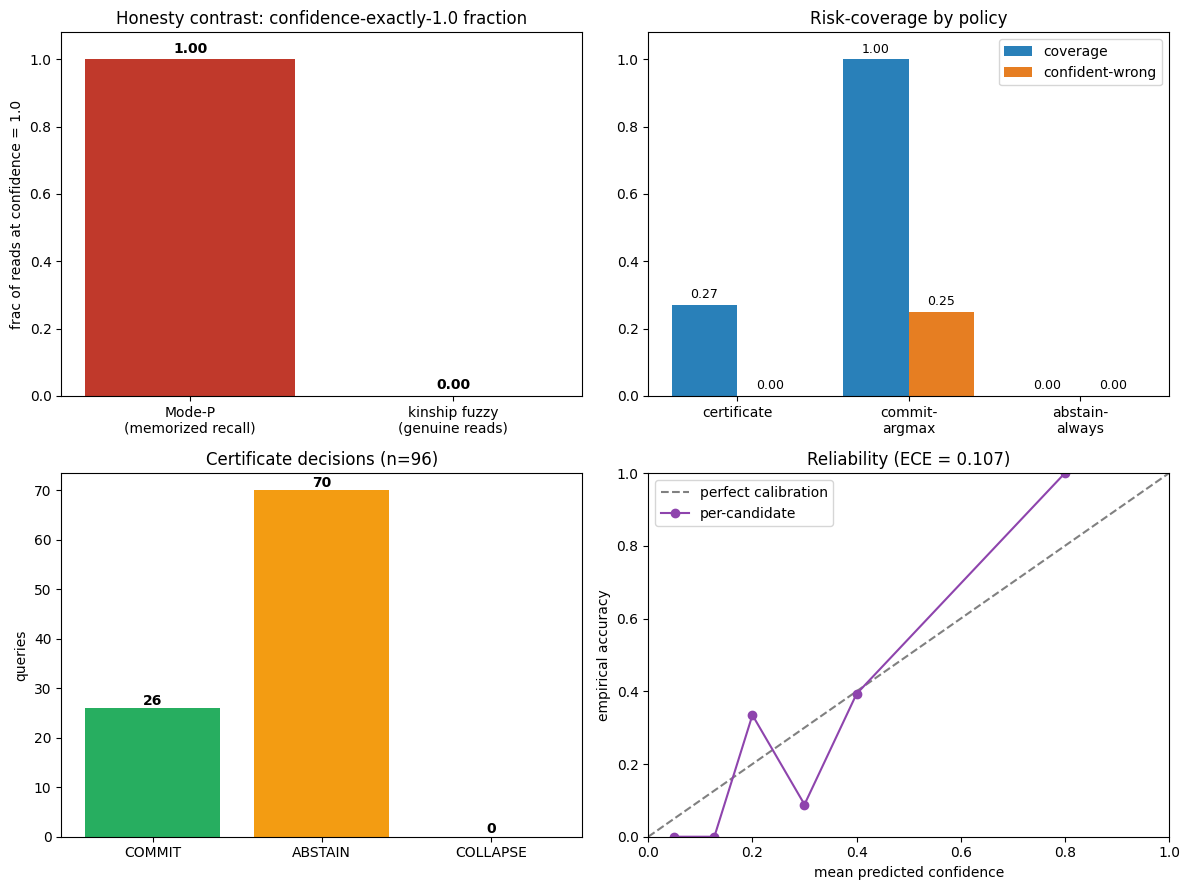

saved figure -> kinship_certificate_demo.png


In [13]:
# --- Summary table + 4-panel figure ---
print("=" * 70)
print("SUMMARY  (kinship / CLUTRR certificate-bounded fuzzy unification)")
print("=" * 70)
print(f"  calibration reads        : {kin_cal['n_reads']}")
print(f"  frac_conf_1p0 (fuzzy)    : {kin_cal['frac_at_conf_1p0']:.2f}   vs Mode-P {modeP['frac_conf_1p0']:.2f}")
print(f"  read soundness rate      : {kin_cal['soundness_rate']:.3f}")
print(f"  ECE (per-candidate)      : {kin_cal['ECE_per_candidate']:.3f}")
print(f"  certificate pool         : {len(kin_pool)} queries")
print(f"  certificate coverage     : {kin_rc['certificate']['coverage']:.3f}  "
      f"(acc among answered = {kin_rc['certificate']['acc_among_answered']})")
print(f"  certificate conf-wrong   : {kin_rc['certificate']['confident_wrong_rate']:.3f}")
print(f"  commit-argmax conf-wrong : {kin_rc['commit_argmax']['confident_wrong_rate']:.3f}")
print(f"  conf-wrong reduction CI  : {[round(x,3) for x in cw_diff['ci95']]}")
print(f"  VERDICT                  : {verdict['label']}")
print("=" * 70)

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# (1) honesty contrast
ax0 = ax[0, 0]
bars = ax0.bar(["Mode-P\n(memorized recall)", "kinship fuzzy\n(genuine reads)"],
               [modeP["frac_conf_1p0"], kin_cal["frac_at_conf_1p0"]],
               color=["#c0392b", "#27ae60"])
ax0.set_ylim(0, 1.08); ax0.set_ylabel("frac of reads at confidence = 1.0")
ax0.set_title("Honesty contrast: confidence-exactly-1.0 fraction")
for b, v in zip(bars, [modeP["frac_conf_1p0"], kin_cal["frac_at_conf_1p0"]]):
    ax0.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

# (2) risk-coverage
ax1 = ax[0, 1]
pols = ["certificate", "commit_argmax", "abstain_always"]
cov  = [kin_rc[p]["coverage"] for p in pols]
cw   = [kin_rc[p]["confident_wrong_rate"] for p in pols]
x = np.arange(len(pols)); w = 0.38
ax1.bar(x - w / 2, cov, w, label="coverage", color="#2980b9")
ax1.bar(x + w / 2, cw,  w, label="confident-wrong", color="#e67e22")
ax1.set_xticks(x); ax1.set_xticklabels(["certificate", "commit-\nargmax", "abstain-\nalways"])
ax1.set_ylim(0, 1.08); ax1.set_title("Risk-coverage by policy"); ax1.legend()
for xi, (c, w_) in enumerate(zip(cov, cw)):
    ax1.text(xi - w / 2, c + 0.02, f"{c:.2f}", ha="center", fontsize=9)
    ax1.text(xi + w / 2, w_ + 0.02, f"{w_:.2f}", ha="center", fontsize=9)

# (3) certificate decision breakdown
ax2 = ax[1, 0]
bd = kin_rc["cert_decision_breakdown"]
labels = list(bd.keys()); vals = [bd[k] for k in labels]
ax2.bar(labels, vals, color=["#27ae60", "#f39c12", "#7f8c8d"])
ax2.set_title(f"Certificate decisions (n={len(kin_pool)})"); ax2.set_ylabel("queries")
for xi, v in enumerate(vals):
    ax2.text(xi, v + max(vals) * 0.01, str(v), ha="center", fontweight="bold")

# (4) reliability diagram (per-candidate)
ax3 = ax[1, 1]
rel = [b for b in kin_cal["reliability_per_candidate"] if b["count"] > 0]
mc = [b["mean_conf"] for b in rel]; ma = [b["mean_acc"] for b in rel]
ax3.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax3.plot(mc, ma, "o-", color="#8e44ad", label="per-candidate")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
ax3.set_xlabel("mean predicted confidence"); ax3.set_ylabel("empirical accuracy")
ax3.set_title(f"Reliability (ECE = {kin_cal['ECE_per_candidate']:.3f})"); ax3.legend()

plt.tight_layout()
plt.savefig("kinship_certificate_demo.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved figure -> kinship_certificate_demo.png")